# *Análisis Modal y Time History en Sentido X*

**`Realizado por:`** Grupo #4 | Dinámica.  
**`Pregrado:`** Ingeniería civil.     
**`Institución:`** Universidad Nacional de Colombia.  

---  
---  

## | *Análisis modal*

#### 1. Importamos librerias

In [1]:
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt
import pandas as pd

#### 2. Masa y Rígidez de la edificación

In [2]:
# Matriz de rigidez condensada en X [kN/m]

Kct = np.array([
    [1290508.6224 ,   -751281.8033,      204343.8969,    -29102.5151],
    [-751281.8033 ,   1092225.8829,      -694852.8885,     152552.5426],
    [204343.8969 ,    -694852.8885 ,       979093.9482 ,   -451738.6672],
    [-29102.5151 ,     152552.5426 ,     -451738.6672 ,     322911.6742]
])  

print("Matriz de rigidez condensada en sentido X en [kN/m]: \n ")
print(Kct)
print("--"*30 + "\n")

pisos = 4                         # número de pisos
Masa_piso = 314.684               # [Ton]

M = np.diag([Masa_piso]*pisos)    # Matríz diagonal de masa en [Ton]
print(f"Matríz de masa del edificio en [Ton]: \n")
print(M)

masa_total = np.sum(np.diag(M))  
print(f"\nMasa total del edificio: {masa_total} Ton\n")

Matriz de rigidez condensada en sentido X en [kN/m]: 
 
[[1290508.6224 -751281.8033  204343.8969  -29102.5151]
 [-751281.8033 1092225.8829 -694852.8885  152552.5426]
 [ 204343.8969 -694852.8885  979093.9482 -451738.6672]
 [ -29102.5151  152552.5426 -451738.6672  322911.6742]]
------------------------------------------------------------

Matríz de masa del edificio en [Ton]: 

[[314.684   0.      0.      0.   ]
 [  0.    314.684   0.      0.   ]
 [  0.      0.    314.684   0.   ]
 [  0.      0.      0.    314.684]]

Masa total del edificio: 1258.736 Ton



#### 3. Periodos y Frecuencias Modales

In [3]:
lamda, PHi   = eigh(Kct , M)

frecuencias = np.sqrt(lamda)
f = frecuencias/(2*np.pi)  # Convertir a Hz
periodos = 2*np.pi/frecuencias

# Creamos el DataFrame
df_modales = pd.DataFrame({
    'Modo': [f'Modo {i+1}' for i in range(len(frecuencias))],
    'ω² [(rad/s)²]': lamda,
    'ω [rad/s]': frecuencias,
    'f [Hz]': f,
    'T [s]': periodos
})

print("\nTabla de propiedades modales en sentido X:")
print(df_modales.round(5))


Tabla de propiedades modales en sentido X:
     Modo  ω² [(rad/s)²]  ω [rad/s]    f [Hz]    T [s]
0  Modo 1       83.77588    9.15292   1.45673  0.68647
1  Modo 2      919.53690   30.32387   4.82619  0.20720
2  Modo 3     3348.11568   57.86290   9.20917  0.10859
3  Modo 4     7357.90574   85.77824  13.65203  0.07325


#### 4. Matríz Modal Ortonormalidad

In [4]:
for i in range(pisos):                    # Normalización de los vectores propios PHi respecto a la matriz de masa M
    phi_i = PHi[:, i]
    r = phi_i.T @ M @ phi_i
    PHi[:, i] = phi_i / np.sqrt(r)

print("Matriz modal ortonormal Φ en sentido X : \n")
print(PHi)
print("-"*30)

print("Chequeos de ortonormalidad en sentido X:")

chequeo1 = np.round(PHi.T@M@PHi,3)
print(chequeo1)
chequeo2 = np.round(PHi.T@Kct@PHi , 3)
print(chequeo2)

Matriz modal ortonormal Φ en sentido X : 

[[ 0.00849663 -0.02525592  0.03776236 -0.03227601]
 [ 0.02166849 -0.03724328  0.00126445  0.03632639]
 [ 0.03273535 -0.00850891 -0.03612735 -0.02699261]
 [ 0.0395534   0.03287045  0.02109527  0.00937243]]
------------------------------
Chequeos de ortonormalidad en sentido X:
[[ 1. -0.  0.  0.]
 [-0.  1. -0. -0.]
 [ 0. -0.  1. -0.]
 [ 0. -0. -0.  1.]]
[[  83.776   -0.       0.       0.   ]
 [  -0.     919.537   -0.      -0.   ]
 [   0.      -0.    3348.116   -0.   ]
 [   0.      -0.      -0.    7357.906]]


#### 5. Participación de Masa Modal

In [5]:
gamma_v =  np.array([1, 1, 1, 1])   # Vector de Colinealidad
alpha   =  PHi.T @ M @gamma_v

participacion_masa_modal = alpha**2/(Masa_piso*4)

print("Suma de a_i²:", np.sum(alpha**2))  
print(f"Chequeo: {np.round(np.sum(alpha**2) - masa_total,3)} \n")

print("Participación de masa modal en sentido X :")
print(participacion_masa_modal , "Total:", np.round(np.sum(participacion_masa_modal) , 3))

Suma de a_i²: 1258.7360000000003
Chequeo: 0.0 

Participación de masa modal en sentido X :
[0.82579346 0.1144255  0.04529461 0.01448642] Total: 1.0


## | *Análisis Modal Time History* 

#### 1. Acelerograma sismo de Armenia 1999 

Aceleración máxima [m/s²]: 5.80102
Aceleración máxima [g]: 0.5915394145809222


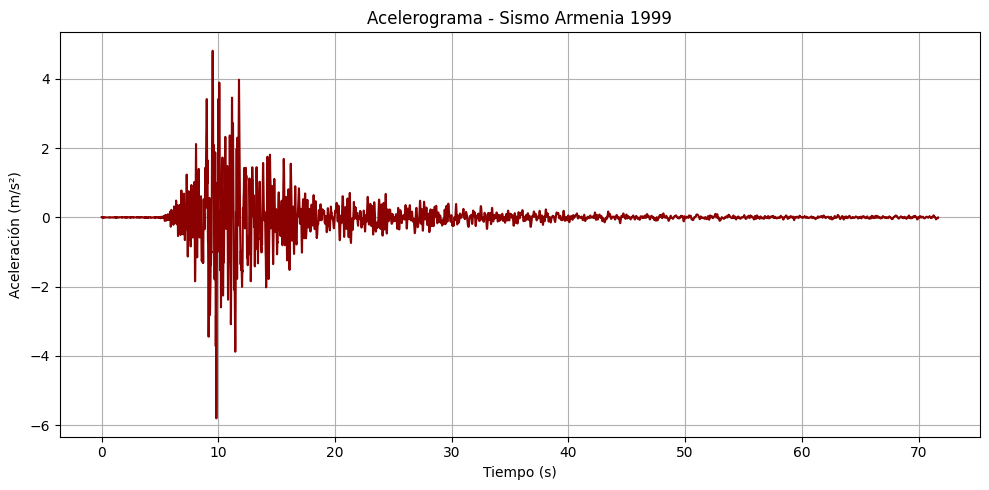

In [6]:
g     =  9.80665                          # Gravedad [m/s²]

data = np.loadtxt('Armenia_1999.txt')     # Se extrae los datos del acelerograma   
tiempo = data[:, 0]
aceleracion = data[:, 1]  

print("Aceleración máxima [m/s²]:", np.max(np.abs(aceleracion)))
print("Aceleración máxima [g]:", np.max(np.abs(aceleracion))/g)

plt.figure(figsize=(10,5))
plt.plot(tiempo, aceleracion, color='darkred')
plt.xlabel('Tiempo (s)')
plt.ylabel('Aceleración (m/s²)')
plt.title('Acelerograma - Sismo Armenia 1999')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2. Implementación Método Newmark-beta

In [7]:
beta  =  1/4                          # Parámetros del método de Newmark-beta
gamma =  1/2

dt    =  0.005                        # Paso de tiempo del acelerograma
n_steps = len(aceleracion)            # Número de pasos de tiempo
n = len(frecuencias)                  # Número de modos

eta     = np.zeros((n_steps, n))      # Se separa la memoria
etadot  = np.zeros((n_steps, n))
etaddot = np.zeros((n_steps, n))

xi = 0.05                             # amortiguamiento crítico (ajustable)

for i in range(n):                                                # Bucle de resolución por modos usando Newmark-beta 
    
    omega = frecuencias[i]                                        # Frecuencia natural del modo i
    m_eff = 1.0                                                   # Masa efectiva del modo i (ajustable, aquí se usa 1.0 Ton)
    c_eff = 2*xi*omega                                            # Amortiguamiento efectivo del modo i
    k_eff = omega**2                                              # Rigidez efectiva del modo i (Ecuación desacoplada)

    eta_i     = 0.0                                               # Desplazamiento inicial del modo i
    etadot_i  = 0.0                                               # Velocidad inicial del modo i
    etaddot_i = -alpha[i]*aceleracion[0]                          # Aceleración inicial del modo i (usando la aceleración del primer paso de tiempo)

    a = m_eff/(beta*dt**2) + gamma*c_eff/(beta*dt)                # Coeficiente a del método de Newmark-beta
    b = m_eff/(beta*dt)    + (gamma/beta - 1)*c_eff
    c = (1/(2*beta) - 1)*m_eff + dt*(gamma/(2*beta) - 1)*c_eff

    k_tilde = k_eff + a

    for j in range(1, n_steps):             # Iteración sobre cada paso de tiempo
        
        p_eff = -alpha[i]*aceleracion[j] + a*eta_i + b*etadot_i + c*etaddot_i
        eta_next = p_eff/k_tilde
        etadot_next = gamma/(beta*dt)*(eta_next - eta_i) + (1 - gamma/beta)*etadot_i + dt*(1 - gamma /(2*beta))*etaddot_i
        etaddot_next = (eta_next - eta_i)/(beta*dt**2) - etadot_i/(beta*dt) - (1 /(2*beta) - 1)*etaddot_i

        eta_i = eta_next                      # Se actualizan las variables para el siguiente paso
        etadot_i = etadot_next
        etaddot_i = etaddot_next

        eta[j, i] = float(eta_i)              # Se almacenan los resultados
        etadot[j, i] = float(etadot_i)
        etaddot[j, i] = float(etaddot_i)

#### 3. Gráficos de desplazamientos por piso:

Desplazamientos X máximos por piso en [m]: [0.02727908 0.06808949 0.10174332 0.12263131]


<Figure size 1200x800 with 0 Axes>

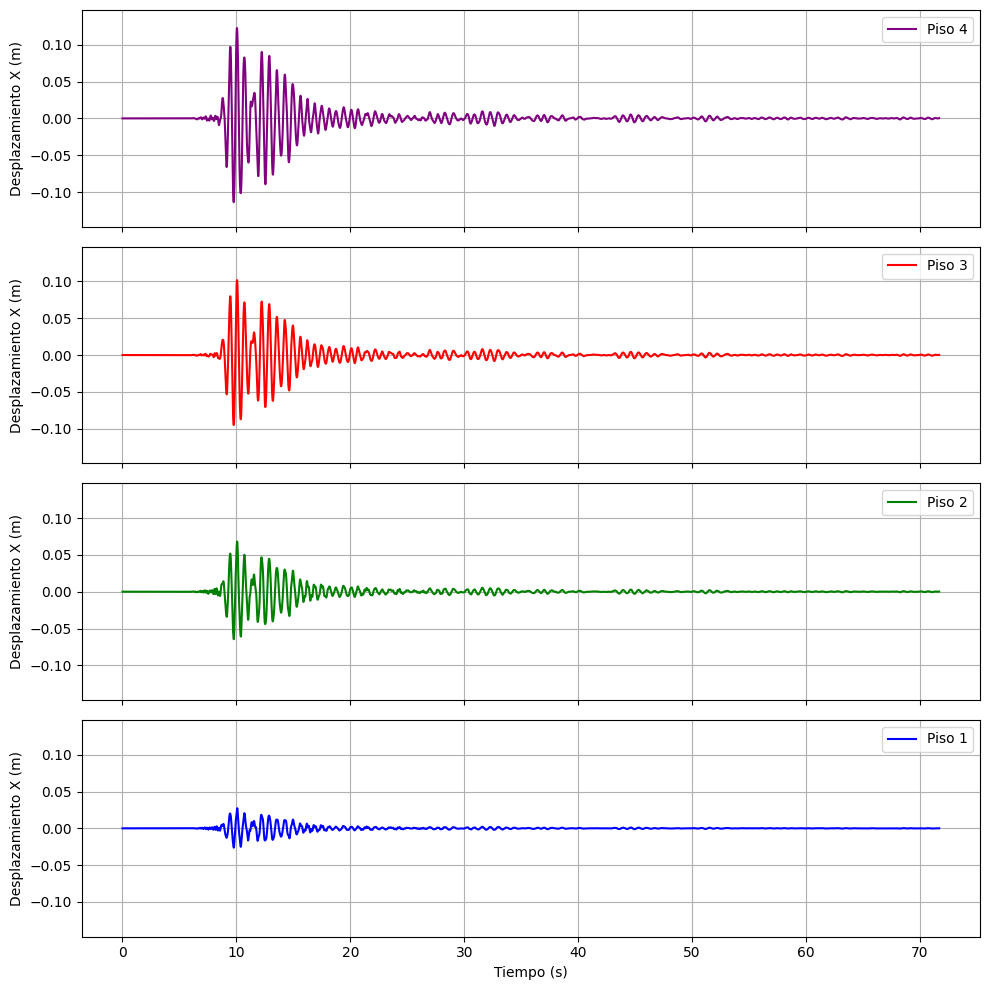

In [8]:
U = eta @ PHi.T     

desplazamientos_maximos = (np.max(np.abs(U), axis=0))       # Se extraen los desplazamientos máximos por piso

print("Desplazamientos X máximos por piso en [m]:", desplazamientos_maximos)

# Proceso para el gráfico

plt.figure(figsize=(12, 8))
colors    = ['blue', 'green', 'red', 'purple']  # Colores para cada piso
fig, axs  = plt.subplots(pisos, 1, figsize=(10, 10), sharex=True)
despl_max = np.max(np.abs(U))*1.2  # +20% de margen

for piso in range(pisos):
    current_ax = axs[pisos - 1 - piso]  
    current_ax.plot(tiempo, U[:, piso], color=colors[piso], label=f'Piso {piso+1}')
    current_ax.set_ylabel('Desplazamiento X (m)')
    current_ax.legend(loc='upper right')
    current_ax.grid(True)
    current_ax.set_ylim(-despl_max, despl_max)

plt.xlabel('Tiempo (s)')
plt.tight_layout()
plt.show()

#### 4. Desplazamientos y Derivas para el tiempo donde el 4 piso obtuvo el máx desplazamiento:

In [9]:
idx_t_max = np.argmax(np.abs(U[:, 3]))  
t_max     = tiempo[idx_t_max]  

print(f"Tiempo con máximo desplazamiento X en Piso 4: {t_max:.2f} s")

eta_tmax = eta[idx_t_max, :]                                           # Extraer los eta en t_max
U_por_modo = PHi*eta_tmax                                              # Se cálculan los desplazamientos físicos por modo en t_max

df_desplazamientos = pd.DataFrame(                                     # Crear DataFrame para visualización
    U_por_modo,
    index=[f'Piso {i+1}' for i in range(pisos)],
    columns=[f'Modo {j+1}' for j in range(n)]
)

print(f"\nDesplazamientos X por piso y modo en t = {t_max:.2f} s [m]:")
print(df_desplazamientos)

print("-"*30)

U_total = np.sum(U_por_modo, axis=1)      # Vector de desplazamientos totales [m]
h_entrepiso = 2.8                                     # Altura entre pisos [m]


# 3. Cálculo de derivas

deriva_piso1 = (U_total[0]/h_entrepiso)*100  # [%]
derivas_pisos_superiores = (np.diff(U_total)/h_entrepiso) * 100  # [%]
derivas_totales = np.concatenate([[deriva_piso1], derivas_pisos_superiores])

print("Desplazamientos totales X en t_max [m]:")
print(pd.Series(U_total, index=[f'Piso {i+1}' for i in range(pisos)]).round(6))

print("-"*30)

print("Derivas X de entrepiso [%]:")
print(pd.Series(derivas_totales, index=[f'Piso {i+1}' for i in range(pisos)]).round(4))

Tiempo con máximo desplazamiento X en Piso 4: 10.04 s

Desplazamientos X por piso y modo en t = 10.04 s [m]:
          Modo 1    Modo 2    Modo 3    Modo 4
Piso 1  0.026271 -0.000363 -0.000257 -0.000017
Piso 2  0.066998 -0.000535 -0.000009  0.000019
Piso 3  0.101217 -0.000122  0.000246 -0.000014
Piso 4  0.122298  0.000472 -0.000144  0.000005
------------------------------
Desplazamientos totales X en t_max [m]:
Piso 1    0.025635
Piso 2    0.066473
Piso 3    0.101326
Piso 4    0.122631
dtype: float64
------------------------------
Derivas X de entrepiso [%]:
Piso 1    0.9155
Piso 2    1.4585
Piso 3    1.2448
Piso 4    0.7609
dtype: float64


#### 5. Fuerzas Inerciales y Cortante de Piso para el tiempo donde el 4 piso obtuvo el máx desplazamiento:

In [10]:
fuerzas_por_modo = Kct@(PHi*eta_tmax)       # Fuerzas inerciales en t_max [kN]

df_fuerzas_modales = pd.DataFrame(
    fuerzas_por_modo,
    index=[f'Piso {i+1}' for i in range(pisos)],
    columns=[f'Modo {j+1}' for j in range(n)]
)

print("Fuerzas inerciales X por modo en t_max [kN]:")
print(df_fuerzas_modales)
print("-"*30)

cortantes_por_modo = np.zeros_like(fuerzas_por_modo)
cortantes_por_modo[-1, :] = fuerzas_por_modo[-1, :]               # Cortante en el último piso = fuerza inercial del último piso (para cada modo)

for piso in range(pisos - 2, -1, -1):                             # Cortantes para pisos inferiores (suma acumulada hacia abajo)
    cortantes_por_modo[piso, :] = cortantes_por_modo[piso + 1, :] + fuerzas_por_modo[piso, :]

df_cortantes_modales = pd.DataFrame(
    cortantes_por_modo,
    index=[f'Piso {i+1}' for i in range(pisos)],
    columns=[f'Modo {j+1}' for j in range(n)]
)

print("\nCortantes de piso X por modo en t_max [kN]:")
print(df_cortantes_modales)
print("-"*30)

fuerzas_totales_srss = np.sum(fuerzas_por_modo, axis=1)         # Fuerzas inerciales totales 
cortantes_totales_srss = np.sum(cortantes_por_modo, axis=1)     # Cortantes totales 

df_totales = pd.DataFrame({
    'Piso': [f'Piso {i+1}' for i in range(pisos)],
    'Fuerza Total [kN]': fuerzas_totales_srss,
    'Cortante Total [kN]': cortantes_totales_srss
})

print("\nFuerzas y cortantes totales X:")
print(df_totales)
print("-"*30)

Fuerzas inerciales X por modo en t_max [kN]:
             Modo 1      Modo 2      Modo 3     Modo 4
Piso 1   692.587938 -105.002440 -270.686346 -38.414354
Piso 2  1766.269179 -154.840330   -9.063774  43.235052
Piso 3  2668.364629  -35.376118  258.966350 -32.126139
Piso 4  3224.126542  136.660116 -151.214128  11.154906
------------------------------

Cortantes de piso X por modo en t_max [kN]:
             Modo 1      Modo 2      Modo 3     Modo 4
Piso 1  8351.348289 -158.558771 -171.997898 -16.150534
Piso 2  7658.760350  -53.556332   98.688448  22.263820
Piso 3  5892.491171  101.283998  107.752221 -20.971232
Piso 4  3224.126542  136.660116 -151.214128  11.154906
------------------------------

Fuerzas y cortantes totales X:
     Piso  Fuerza Total [kN]  Cortante Total [kN]
0  Piso 1         278.484799          8004.641085
1  Piso 2        1645.600129          7726.156287
2  Piso 3        2859.828721          6080.556158
3  Piso 4        3220.727436          3220.727436
----------------

#### 6. Momentos de vuelco para el tiempo donde el 4 piso obtuvo el máx desplazamiento:

In [11]:
h = np.array([2.8, 5.6, 8.4, 11.2])                              # Alturas de los pisos desde la base [m]

momentos_por_piso_modo = np.zeros_like(fuerzas_por_modo)

for modo in range(n):
    for piso in range(pisos):
        # Fuerzas de los pisos SUPERIORES al actual (no incluyéndolo)
        fuerzas_superiores = fuerzas_por_modo[piso+1:, modo] if piso+1 < pisos else np.array([])
        
        # Alturas relativas (desde el piso actual hasta los superiores)
        h_relativas = h[piso+1:] - h[piso] if piso+1 < pisos else np.array([])
        
        # Momento en la parte INFERIOR del piso = Σ(Fuerza * Altura relativa)
        momentos_por_piso_modo[piso, modo] = np.sum(fuerzas_superiores * h_relativas)

# Ajuste para el último piso (techo)
momentos_por_piso_modo[-1, :] = 0  # No hay pisos superiores al techo

# 3. Resultados por modo
df_momentos_piso_modo = pd.DataFrame(
    momentos_por_piso_modo,
    index=[f'Piso {i+1}' for i in range(pisos)],
    columns=[f'Modo {j+1}' for j in range(n)]
)
print("\nMomento de vuelco Y por piso y modo [kN·m]:")
print(df_momentos_piso_modo.round(2))

# 4. Momento total por piso
momento_total_por_piso = np.sum(momentos_por_piso_modo, axis=1)

df_momento_total_piso = pd.DataFrame({
    'Piso': [f'Piso {i+1}' for i in range(pisos)],
    'Momento Total [kN·m]': momento_total_por_piso
})
print("\nMomento de vuelco total Y por piso:")
print(df_momento_total_piso.round(2))


momento_base_por_modo = h@fuerzas_por_modo  

# 3. Resultados por modo
df_momento_base = pd.DataFrame(
    [momento_base_por_modo],
    columns=[f'Modo {j+1}' for j in range(n)],
    index=['Momento en base [kN·m]']
)
print("\nMomento de vuelco en la base por modo (como en el libro):")
print(df_momento_base.round(1))

# 4. Momento total en base 
momento_base_total = np.sum(momento_base_por_modo)
print(f"\nMomento de vuelco TOTAL Y en base: {momento_base_total:.1f} kN·m")


Momento de vuelco Y por piso y modo [kN·m]:
          Modo 1  Modo 2  Modo 3  Modo 4
Piso 1  46971.06  516.29  154.63   34.85
Piso 2  25526.53  666.24 -121.69  -27.49
Piso 3   9027.55  382.65 -423.40   31.23
Piso 4      0.00    0.00    0.00    0.00

Momento de vuelco total Y por piso:
     Piso  Momento Total [kN·m]
0  Piso 1              47676.83
1  Piso 2              26043.59
2  Piso 3               9018.04
3  Piso 4                  0.00

Momento de vuelco en la base por modo (como en el libro):
                         Modo 1  Modo 2  Modo 3  Modo 4
Momento en base [kN·m]  70354.8    72.3  -327.0   -10.4

Momento de vuelco TOTAL Y en base: 70089.8 kN·m
